# Lecture 5 companion: the geometry of the entropy regularizer

This notebook accompanies Section L5.2.4 (*Multiplicative weights update (MWU) as a special case*) of Lecture 5. It

1. checks numerically every property in the lemma on the negative entropy $H(\boldsymbol x) = \sum_a x_a \log x_a$ (range, gradient, strong convexity, Bregman divergence = KL, Pinsker);
2. checks that FTRL and OMD with $\psi = H$ produce exactly the MWU iterates;
3. recomputes the regularization paths of the entropy-vs-Euclidean figure, including the breakpoints $\eta = 5/7$ and $\eta = 5/3$; and
4. offers an **interactive, rotatable** version of the entropy bowl, *tilted* by the FTRL linear term, so you can watch the maximizer $\mathrm{softmax}(\eta \boldsymbol r)$ move as you change $\eta$ and $\boldsymbol r$.

Requirements: `numpy`, `matplotlib`; `ipywidgets` for the interactive cell (optional).

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
rng = np.random.default_rng(0)

def H(x):
    x = np.asarray(x, dtype=float)
    nz = x > 0
    return float(np.sum(x[nz] * np.log(x[nz])))

def grad_H(x):
    return 1 + np.log(x)

def kl(xh, x):
    nz = xh > 0
    return float(np.sum(xh[nz] * np.log(xh[nz] / x[nz])))

def bregman_H(xh, x):
    return H(xh) - H(x) - grad_H(x) @ (xh - x)

def softmax(z):
    w = np.exp(z - z.max())
    return w / w.sum()

def random_interior(m, k):
    return rng.dirichlet(np.ones(m) * rng.uniform(0.2, 3), size=k)

## 1. The lemma, numerically

For random points in the relative interior of $\Delta(A)$, with $m$ ranging over several sizes, we check each item of the lemma.

In [2]:
for m in (2, 3, 5, 20, 100):
    X, Y = random_interior(m, 2000), random_interior(m, 2000)
    # Range: -log m <= H <= 0, with the extremes at uniform / pure strategies.
    h = np.array([H(x) for x in X])
    assert np.all(h >= -math.log(m) - 1e-12) and np.all(h <= 0)
    assert abs(H(np.full(m, 1 / m)) + math.log(m)) < 1e-12 and H(np.eye(m)[0]) == 0
    # Strong convexity w.r.t. l1:  (grad H(x) - grad H(y))^T (x - y) >= ||x - y||_1^2.
    lhs = np.einsum("ij,ij->i", grad_H(X) - grad_H(Y), X - Y)
    rhs = np.abs(X - Y).sum(axis=1) ** 2
    assert np.all(lhs >= rhs - 1e-12)
    # Bregman divergence of H equals KL, and Pinsker: KL >= ||.||_1^2 / 2.
    for xh, x in zip(X[:200], Y[:200]):
        assert abs(bregman_H(xh, x) - kl(xh, x)) < 1e-10
        assert kl(xh, x) >= 0.5 * np.abs(xh - x).sum() ** 2 - 1e-12
    print(f"m = {m:3d}: all properties hold; tightest strong-convexity ratio = {np.min(lhs / rhs):.3f}")

m =   2: all properties hold; tightest strong-convexity ratio = 1.000
m =   3: all properties hold; tightest strong-convexity ratio = 1.003
m =   5: all properties hold; tightest strong-convexity ratio = 1.046
m =  20: all properties hold; tightest strong-convexity ratio = 1.432
m = 100: all properties hold; tightest strong-convexity ratio = 1.779


The *steep boundary* is what forces the maximizers of FTRL and OMD into the interior: the partial derivative $1 + \log x_a$ diverges as $x_a \to 0$.

In [3]:
for xa in (1e-1, 1e-3, 1e-6, 1e-12):
    print(f"x_a = {xa:8.0e}:  dH/dx_a = 1 + log x_a = {1 + math.log(xa):8.2f}")

x_a =    1e-01:  dH/dx_a = 1 + log x_a =    -1.30
x_a =    1e-03:  dH/dx_a = 1 + log x_a =    -5.91
x_a =    1e-06:  dH/dx_a = 1 + log x_a =   -12.82
x_a =    1e-12:  dH/dx_a = 1 + log x_a =   -26.63


## 2. FTRL and OMD with the entropy are MWU

We check the closed form of the FTRL step against a brute-force maximization over a fine grid of the 3-action simplex, and then run FTRL, OMD, and Algorithm L5.3 side by side on a random sequence of utility vectors.

In [4]:
def simplex_grid(n):
    pts = [(i / n, j / n, (n - i - j) / n) for i in range(n + 1) for j in range(n + 1 - i)]
    return np.array(pts)

G3 = simplex_grid(400)
with np.errstate(divide="ignore", invalid="ignore"):
    HG = np.where(G3 > 0, G3 * np.log(G3), 0).sum(axis=1)
for _ in range(5):
    r, eta = rng.normal(size=3), rng.uniform(0.2, 5)
    best = G3[np.argmax(G3 @ r - HG / eta)]
    assert np.abs(best - softmax(eta * r)).max() < 4e-3
print("FTRL step = softmax(eta r): matches brute force on a grid of", len(G3), "points")

m, T, eta = 6, 200, 0.3
gs = rng.uniform(-1, 1, size=(T, m))
x_omd = np.full(m, 1 / m); r = np.zeros(m); cum = np.zeros(m)
for g in gs:
    x_mwu = softmax(eta * r)                         # Algorithm L5.3
    x_ftrl = softmax(eta * cum)                      # FTRL (general version), cumulated gradients
    assert np.allclose(x_mwu, x_ftrl) and np.allclose(x_mwu, x_omd)
    r += g - g @ x_mwu
    cum += g
    x_omd = x_omd * np.exp(eta * g); x_omd /= x_omd.sum()  # OMD multiplicative step
print(f"FTRL, OMD and MWU agree on all {T} iterates")

FTRL step = softmax(eta r): matches brute force on a grid of 80601 points
FTRL, OMD and MWU agree on all 200 iterates


## 3. Regularization paths (Figure: entropy vs. Euclidean)

For $\boldsymbol r = (1, 2/5, 0)$, the entropic FTRL point is $\mathrm{softmax}(\eta \boldsymbol r)$ and the Euclidean one is the projection $\Pi_{\Delta(A)}(\eta \boldsymbol r)$. The text claims the Euclidean path reaches the edge $x_3 = 0$ at $\eta = 5/7$ and the corner $\boldsymbol e_1$ at $\eta = 5/3$, while the entropic path never leaves the interior.

In [5]:
def project_simplex(y):
    u = np.sort(y)[::-1]
    css = np.cumsum(u)
    k = np.nonzero(u - (css - 1) / np.arange(1, len(y) + 1) > 0)[0][-1]
    return np.maximum(y - (css[k] - 1) / (k + 1), 0)

r = np.array([1, 0.4, 0])
etas = np.linspace(0, 3, 30001)
euc = np.array([project_simplex(e * r) for e in etas])
first_edge = etas[np.argmax(euc[:, 2] <= 1e-12)]
first_corner = etas[np.argmax(euc[:, 0] >= 1 - 1e-12)]
print(f"Euclidean path hits x_3 = 0 at eta = {first_edge:.4f}   (5/7 = {5/7:.4f})")
print(f"Euclidean path hits e_1     at eta = {first_corner:.4f}   (5/3 = {5/3:.4f})")
# Interior formula before the boundary: x_eta = 1/3 + eta (r - 7/15).
for e in (0.1, 0.4, 0.7):
    assert np.allclose(project_simplex(e * r), 1 / 3 + e * (r - 7 / 15))
ent_min = min(softmax(e * r).min() for e in np.linspace(0, 50, 1001))
print(f"entropic path: smallest coordinate over eta in [0, 50] = {ent_min:.2e} > 0")

Euclidean path hits x_3 = 0 at eta = 0.7143   (5/7 = 0.7143)
Euclidean path hits e_1     at eta = 1.6667   (5/3 = 1.6667)
entropic path: smallest coordinate over eta in [0, 50] = 1.93e-22 > 0


## 4. Interactive: tilting the bowl

FTRL with the entropy maximizes $\langle \boldsymbol r, \boldsymbol x\rangle - \tfrac1\eta H(\boldsymbol x)$, i.e., it *minimizes* $\tfrac1\eta H(\boldsymbol x) - \langle \boldsymbol r, \boldsymbol x\rangle$: the entropy bowl, scaled by $1/\eta$ and tilted by the linear term. The plot shows this tilted bowl over the 3-action simplex and marks its lowest point, which is exactly $\mathrm{softmax}(\eta \boldsymbol r)$.

* Rotate the view with the *azimuth* and *elevation* sliders.
* With small $\eta$ the bowl is deep and the tilt barely matters: the minimizer stays near the uniform strategy.
* With large $\eta$ the tilt dominates and the minimizer slides towards the corner with the largest $r_a$, but it never reaches it, because the walls of the bowl are vertical at the boundary.

Set $\eta$ very small and the plot is the (scaled) bowl of the lecture figure. If `ipywidgets` is not installed, the cell draws a few fixed settings instead.

In [6]:
CORNERS = np.array([[0.0, 0.0], [1.0, 0.0], [0.5, math.sqrt(3) / 2]])
N = 60
tri_pts = simplex_grid(N)
xy = tri_pts @ CORNERS

def tilted_bowl(eta=1.0, r1=1.0, r2=0.4, r3=0.0, azimuth=-60, elevation=30):
    r = np.array([r1, r2, r3])
    with np.errstate(divide="ignore", invalid="ignore"):
        Hv = np.where(tri_pts > 0, tri_pts * np.log(tri_pts), 0).sum(axis=1)
    z = Hv / eta - tri_pts @ r
    x_star = softmax(eta * r)
    z_star = H(x_star) / eta - x_star @ r
    p_star = x_star @ CORNERS
    fig = plt.figure(figsize=(6.5, 5))
    ax = fig.add_subplot(projection="3d")
    ax.plot_trisurf(xy[:, 0], xy[:, 1], z, cmap="Purples_r", alpha=0.85, linewidth=0)
    ax.scatter(*p_star, z_star, color="k", s=40, depthshade=False)
    ax.text(*p_star, z_star, "  softmax(eta r)", fontsize=9)
    for k, name in enumerate(["e1", "e2", "e3"]):
        ax.text(*CORNERS[k], z[np.argmax((tri_pts[:, k] == 1))], name)
    ax.view_init(elev=elevation, azim=azimuth)
    ax.set_xticks([]); ax.set_yticks([]); ax.set_zlabel("H(x)/eta - <r, x>")
    ax.set_title(f"eta = {eta:.2f},  argmin = ({x_star[0]:.2f}, {x_star[1]:.2f}, {x_star[2]:.2f})")
    plt.show()

try:
    from ipywidgets import interact, FloatLogSlider, FloatSlider, IntSlider
    interact(
        tilted_bowl,
        eta=FloatLogSlider(value=1.0, base=10, min=-2, max=1.3, step=0.05),
        r1=FloatSlider(value=1.0, min=-1, max=1, step=0.05),
        r2=FloatSlider(value=0.4, min=-1, max=1, step=0.05),
        r3=FloatSlider(value=0.0, min=-1, max=1, step=0.05),
        azimuth=IntSlider(value=-60, min=-180, max=180, step=5),
        elevation=IntSlider(value=30, min=-10, max=90, step=5),
    )
except ImportError:
    for eta in (0.05, 1.0, 8.0):
        tilted_bowl(eta)

interactive(children=(FloatLogSlider(value=1.0, description='eta', max=1.3, min=-2.0, step=0.05), FloatSlider(…

## 5. Why the dependence on the number of actions differs

The lecture explains that the entropy gives a bound of order $\sqrt{T \log m}$ while the Euclidean regularizer gives $\sqrt{T m}$: the entropy has a larger range $B = \log m$ (versus $B < 1/2$), but it is strongly convex with respect to $\|\cdot\|_1$, whose dual norm $\|\boldsymbol g\|_\infty \le 1$ does not grow with $m$, whereas $\|\boldsymbol g\|_2^2$ can be as large as $m$. The plot compares the two tuned guarantees, $2\sqrt{T \log m}$ (Theorem L5.6) and $\sqrt{2 T m}$ (Theorem L5.20), for $T = 10^4$.

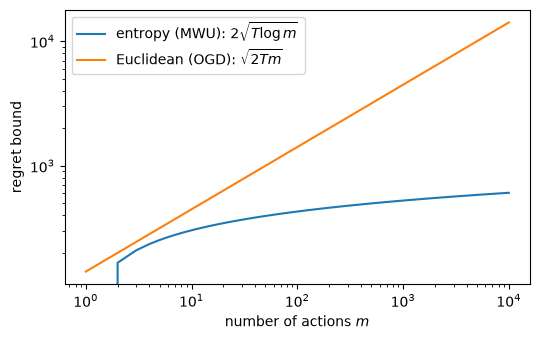

In [7]:
T = 10_000
ms = np.unique(np.logspace(0.3, 4, 60).astype(int))
plt.figure(figsize=(5.5, 3.5))
plt.loglog(ms, 2 * np.sqrt(T * np.log(ms)), label=r"entropy (MWU): $2\sqrt{T\log m}$")
plt.loglog(ms, np.sqrt(2 * T * ms), label=r"Euclidean (OGD): $\sqrt{2Tm}$")
plt.xlabel("number of actions $m$"); plt.ylabel("regret bound"); plt.legend(); plt.tight_layout(); plt.show()